# Your Title Here

**Name(s)**: (your name(s) here)

**Website Link**: (your website link)

In [377]:
# !pip install tabulate

In [427]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
import tabulate
import seaborn as sns

pd.options.plotting.backend = "plotly"

# from dsc80_utils import * # Feel free to uncomment and use this.

In [379]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 500)
pd.set_option("display.max_colwidth", 200)

In [380]:
df = pd.read_excel(Path("data", "outage.xlsx"))
df.head(10)

,Major power outage events in the continental U.S.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56
0,Time period: January 2000 - July 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Regions affected: Outages reported in this data file affected a single U.S. state at the time of occurrence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,variables,OBS,YEAR,MONTH,U.S._STATE,POSTAL.CODE,NERC.REGION,CLIMATE.REGION,ANOMALY.LEVEL,CLIMATE.CATEGORY,OUTAGE.START.DATE,OUTAGE.START.TIME,OUTAGE.RESTORATION.DATE,OUTAGE.RESTORATION.TIME,CAUSE.CATEGORY,CAUSE.CATEGORY.DETAIL,HURRICANE.NAMES,OUTAGE.DURATION,DEMAND.LOSS.MW,CUSTOMERS.AFFECTED,RES.PRICE,COM.PRICE,IND.PRICE,TOTAL.PRICE,RES.SALES,COM.SALES,IND.SALES,TOTAL.SALES,RES.PERCEN,COM.PERCEN,IND.PERCEN,RES.CUSTOMERS,COM.CUSTOMERS,IND.CUSTOMERS,TOTAL.CUSTOMERS,RES.CUST.PCT,COM.CUST.PCT,IND.CUST.PCT,PC.REALGSP.STATE,PC.REALGSP.USA,PC.REALGSP.REL,PC.REALGSP.CHANGE,UTIL.REALGSP,TOTAL.REALGSP,UTIL.CONTRI,PI.UTIL.OFUSA,POPULATION,POPPCT_URBAN,POPPCT_UC,POPDEN_URBAN,POPDEN_UC,POPDEN_RURAL,AREAPCT_URBAN,AREAPCT_UC,PCT_LAND,PCT_WATER_TOT,PCT_WATER_INLAND
5,Units,NaN,NaN,NaN,NaN,NaN,NaN,NaN,numeric,NaN,"Day of the week, Month Day, Year",Hour:Minute:Second (AM / PM),"Day of the week, Month Day, Year",Hour:Minute:Second (AM / PM),NaN,NaN,NaN,mins,Megawatt,NaN,cents / kilowatt-hour,cents / kilowatt-hour,cents / kilowatt-hour,cents / kilowatt-hour,Megawatt-hour,Megawatt-hour,Megawatt-hour,Megawatt-hour,%,%,%,NaN,NaN,NaN,NaN,%,%,%,USD,USD,fraction,%,USD,USD,%,%,NaN,%,%,persons per square mile,persons per square mile,persons per square mile,%,%,%,%,%
6,NaN,1,2011,7,Minnesota,MN,MRO,East North Central,-0.3,normal,2011-07-01 00:00:00,17:00:00,2011-07-03 00:00:00,20:00:00,severe weather,NaN,NaN,3060,NaN,70000,11.6,9.18,6.81,9.28,2332915,2114774,2113291,6562520,35.549073,32.225029,32.202431,2308736,276286,10673,2595696,88.944776,10.644005,0.411181,51268,47586,1.077376,1.6,4802,274182,1.751391,2.2,5348119,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
7,NaN,2,2014,5,Minnesota,MN,MRO,East North Central,-0.1,normal,2014-05-11 00:00:00,18:38:00,2014-05-11 00:00:00,18:39:00,intentional attack,vandalism,NaN,1,NaN,NaN,12.12,9.71,6.49,9.28,1586986,1807756,1887927,5284231,30.032487,34.210389,35.727564,2345860,284978,9898,2640737,88.833534,10.791609,0.37482,53499,49091,1.089792,1.9,5226,291955,1.790002,2.2,5457125,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
8,NaN,3,2010,10,Minnesota,MN,MRO,East North Central,-1.5,cold,2010-10-26 00:00:00,20:00:00,2010-10-28 00:00:00,22:00:

In [381]:
df = df.iloc[4:, 1:].reset_index(drop=True)
df.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56
0,OBS,YEAR,MONTH,U.S._STATE,POSTAL.CODE,NERC.REGION,CLIMATE.REGION,ANOMALY.LEVEL,CLIMATE.CATEGORY,OUTAGE.START.DATE,OUTAGE.START.TIME,OUTAGE.RESTORATION.DATE,OUTAGE.RESTORATION.TIME,CAUSE.CATEGORY,CAUSE.CATEGORY.DETAIL,HURRICANE.NAMES,OUTAGE.DURATION,DEMAND.LOSS.MW,CUSTOMERS.AFFECTED,RES.PRICE,COM.PRICE,IND.PRICE,TOTAL.PRICE,RES.SALES,COM.SALES,IND.SALES,TOTAL.SALES,RES.PERCEN,COM.PERCEN,IND.PERCEN,RES.CUSTOMERS,COM.CUSTOMERS,IND.CUSTOMERS,TOTAL.CUSTOMERS,RES.CUST.PCT,COM.CUST.PCT,IND.CUST.PCT,PC.REALGSP.STATE,PC.REALGSP.USA,PC.REALGSP.REL,PC.REALGSP.CHANGE,UTIL.REALGSP,TOTAL.REALGSP,UTIL.CONTRI,PI.UTIL.OFUSA,POPULATION,POPPCT_URBAN,POPPCT_UC,POPDEN_URBAN,POPDEN_UC,POPDEN_RURAL,AREAPCT_URBAN,AREAPCT_UC,PCT_LAND,PCT_WATER_TOT,PCT_WATER_INLAND
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,numeric,NaN,"Day of the week, Month Day, Year",Hour:Minute:Second (AM / PM),"Day of the week, Month Day, Year",Hour:Minute:Second (AM / PM),NaN,NaN,NaN,mins,Megawatt,NaN,cents / kilowatt-hour,cents / kilowatt-hour,cents / kilowatt-hour,cents / kilowatt-hour,Megawatt-hour,Megawatt-hour,Megawatt-hour,Megawatt-hour,%,%,%,NaN,NaN,NaN,NaN,%,%,%,USD,USD,fraction,%,USD,USD,%,%,NaN,%,%,persons per square mile,persons per square mile,persons per square mile,%,%,%,%,%
2,1,2011,7,Minnesota,MN,MRO,East North Central,-0.3,normal,2011-07-01 00:00:00,17:00:00,2011-07-03 00:00:00,20:00:00,severe weather,NaN,NaN,3060,NaN,70000,11.6,9.18,6.81,9.28,2332915,2114774,2113291,6562520,35.549073,32.225029,32.202431,2308736,276286,10673,2595696,88.944776,10.644005,0.411181,51268,47586,1.077376,1.6,4802,274182,1.751391,2.2,5348119,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
3,2,2014,5,Minnesota,MN,MRO,East North Central,-0.1,normal,2014-05-11 00:00:00,18:38:00,2014-05-11 00:00:00,18:39:00,intentional attack,vandalism,NaN,1,NaN,NaN,12.12,9.71,6.49,9.28,1586986,1807756,1887927,5284231,30.032487,34.210389,35.727564,2345860,284978,9898,2640737,88.833534,10.791609,0.37482,53499,49091,1.089792,1.9,5226,291955,1.790002,2.2,5457125,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
4,3,2010,10,Minnesota,MN,MRO,East North Central,-1.5,cold,2010-10-26 00:00:00,20:00:00,2010-10-28 00:00:00,22:00:00,severe weather,heavy wind,NaN,3000,NaN,70000,10.87,8.19,6.07,8.15,1467293,1801683,1951295,5222116,28.097672,34.501015,37.365983,2300291,276463,10150,2586905,88.920583,10.687018,0.392361,50447,47287,1.066826,2.7,4571,267895,1.706266,2.1,5310903,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743


In [382]:
mapping_dict = {key: "" for key in df.iloc[1].unique()}
mapping_dict["cents / kilowatt-hour"] = "(cents / kWh)"
mapping_dict["USD"] = "($)"
mapping_dict["persons per square mile"] = "(people / sq mi)"
mapping_dict["%"] = "(%)"
df.iloc[0] = df.iloc[0].str.replace(".", "_").str.capitalize()
df.iloc[1] = df.iloc[1].map(mapping_dict)
df.iloc[0] = df.iloc[0].astype(str) + " " + df.iloc[1].astype(str)
df.columns = df.iloc[0].str.strip()
df = df.iloc[2:].set_index("Obs", drop=True)
df = df.rename(columns={"U_s__state": "US_state"})
df.head()

,Year,Month,US_state,Postal_code,Nerc_region,Climate_region,Anomaly_level,Climate_category,Outage_start_date,Outage_start_time,Outage_restoration_date,Outage_restoration_time,Cause_category,Cause_category_detail,Hurricane_names,Outage_duration,Demand_loss_mw,Customers_affected,Res_price (cents / kWh),Com_price (cents / kWh),Ind_price (cents / kWh),Total_price (cents / kWh),Res_sales,Com_sales,Ind_sales,Total_sales,Res_percen (%),Com_percen (%),Ind_percen (%),Res_customers,Com_customers,Ind_customers,Total_customers,Res_cust_pct (%),Com_cust_pct (%),Ind_cust_pct (%),Pc_realgsp_state ($),Pc_realgsp_usa ($),Pc_realgsp_rel,Pc_realgsp_change (%),Util_realgsp ($),Total_realgsp ($),Util_contri (%),Pi_util_ofusa (%),Population,Poppct_urban (%),Poppct_uc (%),Popden_urban (people / sq mi),Popden_uc (people / sq mi),Popden_rural (people / sq mi),Areapct_urban (%),Areapct_uc (%),Pct_land (%),Pct_water_tot (%),Pct_water_inland (%)
Obs,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2011,7,Minnesota,MN,MRO,East North Central,-0.3,normal,2011-07-01 00:00:00,17:00:00,2011-07-03 00:00:00,20:00:00,severe weather,NaN,NaN,3060,NaN,70000,11.6,9.18,6.81,9.28,2332915,2114774,2113291,6562520,35.549073,32.225029,32.202431,2308736,276286,10673,2595696,88.944776,10.644005,0.411181,51268,47586,1.077376,1.6,4802,274182,1.751391,2.2,5348119,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
2,2014,5,Minnesota,MN,MRO,East North Central,-0.1,normal,2014-05-11 00:00:00,18:38:00,2014-05-11 00:00:00,18:39:00,intentional attack,vandalism,NaN,1,NaN,NaN,12.12,9.71,6.49,9.28,1586986,1807756,1887927,5284231,30.032487,34.210389,35.727564,2345860,284978,9898,2640737,88.833534,10.791609,0.37482,53499,49091,1.089792,1.9,5226,291955,1.790002,2.2,5457125,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
3,2010,10,Minnesota,MN,MRO,East North Central,-1.5,cold,2010-10-26 00:00:00,20:00:00,2010-10-28 00:00:00,22:00:00,severe weather,heavy wind,NaN,3000,NaN,70000,10.87,8.19,6.07,8.15,1467293,1801683,1951295,5222116,28.097672,34.501015,37.365983,2300291,276463,10150,2586905,88.920583,10.687018,0.392361,50447,47287,1.066826,2.7,4571,267895,1.706266,2.1,5310903,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
4,2012,6,Minnesota,MN,MRO,East North Central,-0.1,normal,2012-06-19 00:00:00,04:30:00,2012-06-20 00:00:00,23:00:00,severe weather,thunderstorm,NaN,2550,NaN,68200,11.79,9.25,6.71,9.19,1851519,1941174,1993026,5787064,31.994099,33.54333,34.439329,2317336,278466,11010,2606813,88.895368,10.682239,0.422355,51598,48156,1.071476,0.6,5364,277627,1.932089,2.2,5380443,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743
5,2015,7,Minnesota,MN,MRO,East North Central,1.2,warm,2015-07-18 00:00:00,02:00:00,2015-07-19 00:00:00,07:00:00,severe weather,NaN,NaN,1740,250,250000,13.07,10.16,7.74,10.43,2028875,2161612,1777937,5970339,33.982576,36.20585,29.779498,2374674,289044,9812,2673531,88.821637,10.81132,0.367005,54431,49844,1.092027,1.7,4873,292023,1.668704,2.2,5489594,73.27,15.28,2279,1700.5,18.2,2.14,0.6,91.592666,8.407334,5.478743


In [383]:
df.describe()

/var/folders/_h/6x5r9mdd0j5fcx_dg0yzyh9w0000gn/T/ipykernel_62489/3627053830.py:1: FutureWarning:

The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`

/var/folders/_h/6x5r9mdd0j5fcx_dg0yzyh9w0000gn/T/ipykernel_62489/3627053830.py:1: FutureWarning:

The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`



,Year,Month,US_state,Postal_code,Nerc_region,Climate_region,Anomaly_level,Climate_category,Outage_start_date,Outage_start_time,Outage_restoration_date,Outage_restoration_time,Cause_category,Cause_category_detail,Hurricane_names,Outage_duration,Demand_loss_mw,Customers_affected,Res_price (cents / kWh),Com_price (cents / kWh),Ind_price (cents / kWh),Total_price (cents / kWh),Res_sales,Com_sales,Ind_sales,Total_sales,Res_percen (%),Com_percen (%),Ind_percen (%),Res_customers,Com_customers,Ind_customers,Total_customers,Res_cust_pct (%),Com_cust_pct (%),Ind_cust_pct (%),Pc_realgsp_state ($),Pc_realgsp_usa ($),Pc_realgsp_rel,Pc_realgsp_change (%),Util_realgsp ($),Total_realgsp ($),Util_contri (%),Pi_util_ofusa (%),Population,Poppct_urban (%),Poppct_uc (%),Popden_urban (people / sq mi),Popden_uc (people / sq mi),Popden_rural (people / sq mi),Areapct_urban (%),Areapct_uc (%),Pct_land (%),Pct_water_tot (%),Pct_water_inland (%)
count,1534,1525,1534,1534,1534,1528,1525.0,1525,1525,1525,1476,1476,1534,1063,72,1476,829,1091,1512.00,1512.00,1512.00,1512.00,1512,1512,1512,1512,1512.000000,1512.000000,1512.000000,1534,1534,1534,1534,1534.000000,1534.000000,1534.000000,1534,1534,1534.000000,1534.0,1534,1534,1534.000000,1534.0,1534,1534.00,1534.00,1534.0,1524.0,1524.0,1534.00,1534.00,1534.000000,1534.000000,1534.000000
unique,17,12,50,50,14,9,36.0,3,1028,622,1100,557,7,52,22,852,282,569,647.00,582.00,542.00,623.00,979,979,979,979,979.000000,979.000000,979.000000,405,405,393,405,405.000000,405.000000,405.000000,402,17,404.000000,95.0,396,405,405.000000,75.0,405,50.00,50.00,50.0,49.0,47.0,46.00,46.00,50.000000,50.000000,50.000000
top,2011,6,California,CA,WECC,Northeast,-0.3,normal,2012-10-29 00:00:00,15:00:00,2011-08-29 00:00:00,12:00:00,severe weather,vandalism,Sandy,1,0,0,14.27,13.49,5.85,8.86,1726552,2344747,340510,4452722,38.775203,52.658733,7.647232,2837631,354185,27845,3219667,88.134301,11.000672,0.864841,52822,47586,1.110032,1.5,3832,360358,1.063387,2.2,6823229,94.95,5.22,4303.7,2124.1,12.7,5.28,0.59,95.164177,4.835823,1.730658
freq,269,195,210,210,451,350,191.0,744,19,35,8,74,763,335,17,97,196,212,11.00,12.00,18.00,11.00,8,8,8,8,8.000000,8.000000,8.000000,29,29,29,29,29.000000,29.000000,29.000000,29,269,29.000000,65.0,29,29,29.000000,92.0,29,210.00,210.00,210.0,210.0,210.0,210.00,210.00,210.000000,210.000000,210.000000


In [384]:
df.isna().sum()

0
Year                                0
Month                               9
US_state                            0
Postal_code                         0
Nerc_region                         0
Climate_region                      6
Anomaly_level                       9
Climate_category                    9
Outage_start_date                   9
Outage_start_time                   9
Outage_restoration_date            58
Outage_restoration_time            58
Cause_category                      0
Cause_category_detail             471
Hurricane_names                  1462
Outage_duration                    58
Demand_loss_mw                    705
Customers_affected                443
Res_price (cents / kWh)            22
Com_price (cents / kWh)            22
Ind_price (cents / kWh)            22
Total_price (cents / kWh)          22
Res_sales                          22
Com_sales                          22
Ind_sales                          22
Total_sales                        22
Res_percen

In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1534 entries, 1 to 1534
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Year                           1534 non-null   object
 1   Month                          1525 non-null   object
 2   US_state                       1534 non-null   object
 3   Postal_code                    1534 non-null   object
 4   Nerc_region                    1534 non-null   object
 5   Climate_region                 1528 non-null   object
 6   Anomaly_level                  1525 non-null   object
 7   Climate_category               1525 non-null   object
 8   Outage_start_date              1525 non-null   object
 9   Outage_start_time              1525 non-null   object
 10  Outage_restoration_date        1476 non-null   object
 11  Outage_restoration_time        1476 non-null   object
 12  Cause_category                 1534 non-null   object
 13  Cause_ca

In [386]:
df.columns

Index(['Year', 'Month', 'US_state', 'Postal_code', 'Nerc_region', 'Climate_region', 'Anomaly_level', 'Climate_category', 'Outage_start_date', 'Outage_start_time', 'Outage_restoration_date', 'Outage_restoration_time', 'Cause_category', 'Cause_category_detail', 'Hurricane_names', 'Outage_duration', 'Demand_loss_mw', 'Customers_affected', 'Res_price (cents / kWh)', 'Com_price (cents / kWh)', 'Ind_price (cents / kWh)', 'Total_price (cents / kWh)', 'Res_sales', 'Com_sales', 'Ind_sales',
       'Total_sales', 'Res_percen (%)', 'Com_percen (%)', 'Ind_percen (%)', 'Res_customers', 'Com_customers', 'Ind_customers', 'Total_customers', 'Res_cust_pct (%)', 'Com_cust_pct (%)', 'Ind_cust_pct (%)', 'Pc_realgsp_state ($)', 'Pc_realgsp_usa ($)', 'Pc_realgsp_rel', 'Pc_realgsp_change (%)', 'Util_realgsp ($)', 'Total_realgsp ($)', 'Util_contri (%)', 'Pi_util_ofusa (%)', 'Population', 'Poppct_urban (%)', 'Poppct_uc (%)', 'Popden_urban (people / sq mi)', 'Popden_uc (people / sq mi)',
       'Popden_rural (p

In [387]:
df.dtypes

0
Year                             object
Month                            object
US_state                         object
Postal_code                      object
Nerc_region                      object
Climate_region                   object
Anomaly_level                    object
Climate_category                 object
Outage_start_date                object
Outage_start_time                object
Outage_restoration_date          object
Outage_restoration_time          object
Cause_category                   object
Cause_category_detail            object
Hurricane_names                  object
Outage_duration                  object
Demand_loss_mw                   object
Customers_affected               object
Res_price (cents / kWh)          object
Com_price (cents / kWh)          object
Ind_price (cents / kWh)          object
Total_price (cents / kWh)        object
Res_sales                        object
Com_sales                        object
Ind_sales                        objec

## Step 1: Introduction

## Step 2: Data Cleaning and Exploratory Data Analysis

In [388]:
# TODO
# data cleaning

cleaned_df = df[
    [
        "US_state",
        "Year",
        "Pc_realgsp_state ($)",
        "Outage_start_date",
        "Outage_start_time",
        "Outage_restoration_date",
        "Outage_restoration_time",
        "Total_price (cents / kWh)",
        "Cause_category",
        "Demand_loss_mw",
        "Customers_affected",
        "Total_sales",
    ]
].copy()

cleaned_df["Outage_start_date"] = pd.to_datetime(
    cleaned_df["Outage_start_date"], errors="coerce"
)

cleaned_df["Outage_restoration_date"] = pd.to_datetime(
    cleaned_df["Outage_restoration_date"], errors="coerce"
)


cleaned_df["Outage_start_time"] = pd.to_datetime(
    cleaned_df["Outage_start_time"], format="%H:%M:%S", errors="coerce"
).dt.time

cleaned_df["Outage_restoration_time"] = pd.to_datetime(
    cleaned_df["Outage_restoration_time"], format="%H:%M:%S", errors="coerce"
).dt.time

start = cleaned_df["Outage_start_date"] + pd.to_timedelta(
    cleaned_df["Outage_start_time"].astype(str)
)

end = cleaned_df["Outage_restoration_date"] + pd.to_timedelta(
    cleaned_df["Outage_restoration_time"].astype(str)
)

cleaned_df["Outage_duration"] = (end - start).dt.total_seconds() / 3600

cleaned_df.loc[cleaned_df["Outage_duration"] < 0, "Outage_duration"] = np.nan


cleaned_df = cleaned_df.drop(
    columns=[
        "Outage_start_date",
        "Outage_start_time",
        "Outage_restoration_date",
        "Outage_restoration_time",
    ]
)
print(cleaned_df.head().to_markdown())
# cleaned_df[
#     cleaned_df[["Demand_loss_mw", "Customers_affected", "Demand_loss_mw"]]
#     .isna()
#     .any(axis=1)
# ]

|   Obs | US_state   |   Year |   Pc_realgsp_state ($) |   Total_price (cents / kWh) | Cause_category     |   Demand_loss_mw |   Customers_affected |   Total_sales |   Outage_duration |
|------:|:-----------|-------:|-----------------------:|----------------------------:|:-------------------|-----------------:|---------------------:|--------------:|------------------:|
|     1 | Minnesota  |   2011 |                  51268 |                        9.28 | severe weather     |              nan |                70000 |       6562520 |        51         |
|     2 | Minnesota  |   2014 |                  53499 |                        9.28 | intentional attack |              nan |                  nan |       5284231 |         0.0166667 |
|     3 | Minnesota  |   2010 |                  50447 |                        8.15 | severe weather     |              nan |                70000 |       5222116 |        50         |
|     4 | Minnesota  |   2012 |                  51598 |              

In [389]:
fig = px.histogram(
    cleaned_df,
    x="Outage_duration",
    nbins=50,
    title="Distribution of Outage Duration (hours)",
    labels={"Outage_duration": "Outage Duration (hours)"},
)
fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/dist_of_outage_duration.html"
# )

In [390]:
fig = px.histogram(
    cleaned_df,
    x="Pc_realgsp_state ($)",
    nbins=20,
    title="Distribution of Real GSP per State ($)",
)
fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/dist_of_real_GSP_per_state.html"
# )

In [391]:
px.scatter(
    cleaned_df,
    x="Total_price (cents / kWh)",
    y="Outage_duration",
    title="Scatter Plot of Residential Price vs Outage Duration",
    labels={
        "Total_price (cents / kWh)": "Residential Price (cents / kWh)",
        "Outage_duration": "Outage Duration (seconds)",
    },
)

In [392]:
median_df = cleaned_df.groupby("Cause_category", as_index=False)[
    "Outage_duration"
].median()

fig = px.bar(
    median_df,
    x="Cause_category",
    y="Outage_duration",
    title="Median Outage Duration by Cause Category",
    labels={
        "Cause_category": "Cause Category",
        "Outage_duration": "Median Outage Duration (hours)",
    },
    color="Cause_category",
    color_discrete_sequence=px.colors.qualitative.Set3,
)

fig.update_layout(showlegend=False)

fig.show()
fig.write_html(
    "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/median_outage_duration_by_cause.html"
)

In [393]:
import folium
import pandas as pd

state_counts = (
    cleaned_df.groupby("US_state").size().reset_index(name="num_outages")
)

url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"

m1 = folium.Map(location=[37.8, -96], zoom_start=4)

folium.Choropleth(
    geo_data=url,
    data=state_counts,
    columns=["US_state", "num_outages"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Number of Power Outages",
).add_to(m1)

m1.save(
    "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/number_of_power_outage.html"
)

In [394]:
state_duration = (
    cleaned_df.groupby("US_state")["Outage_duration"].mean().reset_index()
)

m2 = folium.Map(location=[37.8, -96], zoom_start=4)

folium.Choropleth(
    geo_data=url,
    data=state_duration,
    columns=["US_state", "Outage_duration"],
    key_on="feature.properties.name",
    fill_color="PuBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Average Restoration Time (hours)",
).add_to(m2)

m2.save(
    "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/avg_outage_duration_map.html"
)

In [395]:
# Aggregate analysis
pivot = cleaned_df.pivot_table(
    values="Outage_duration",
    index="Cause_category",
    columns="Year",
    aggfunc="median",
)
print(pivot.to_markdown())

| Cause_category                |      2000 |      2001 |      2002 |      2003 |      2004 |      2005 |     2006 |       2007 |      2008 |      2009 |      2010 |       2011 |      2012 |       2013 |       2014 |       2015 |      2016 |
|:------------------------------|----------:|----------:|----------:|----------:|----------:|----------:|---------:|-----------:|----------:|----------:|----------:|-----------:|----------:|-----------:|-----------:|-----------:|----------:|
| equipment failure             | nan       |   8.23333 | nan       |   2.59167 |   3.68333 |   2.48333 |   2.65   |   3.43333  |   4.48333 |  15.45    |   4.91667 |  0.0666667 |  1.75     |   3.25833  | nan        | nan        | nan       |
| fuel supply emergency         | nan       | nan       | nan       | nan       | nan       | nan       | nan      |  27.9333   | 396       | 109.5     | 168       | 78.75      | 60        |  43.7167   |  93.575    |   4.25     | 568.367   |
| intentional attack            

## Step 3: Assessment of Missingness

In [396]:
# missing values
cleaned_df.isna().sum() / cleaned_df.shape[0]

0
US_state                     0.000000
Year                         0.000000
Pc_realgsp_state ($)         0.000000
Total_price (cents / kWh)    0.014342
Cause_category               0.000000
Demand_loss_mw               0.459583
Customers_affected           0.288787
Total_sales                  0.014342
Outage_duration              0.037810
dtype: float64

In [397]:
cat_cols = ["US_state", "Year", "Cause_category"]
quan_cols = [
    "Pc_realgsp_state ($)",
    "Total_price (cents / kWh)",
    "Demand_loss_mw",
    "Customers_affected",
    "Total_sales",
    "Outage_duration",
]


def missingness_perm_test(df, miss_col, dep_col, test_stat, n_perm=1000):

    # missingness indicator
    missing = df[miss_col].isna()

    # observed statistic
    obs = test_stat(df, missing, dep_col)

    stats = []

    for _ in range(n_perm):

        shuffled = np.random.permutation(missing)

        stat = test_stat(df, shuffled, dep_col)

        stats.append(stat)

    p_value = np.mean(np.array(stats) >= obs)

    return p_value


def tvd_stat(df, missing, dep_col):

    dist = (
        pd.DataFrame({"dep": df[dep_col], "missing": missing})
        .groupby("dep")["missing"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    overall = pd.Series(missing).value_counts(normalize=True)

    tvd = 0.5 * np.abs(dist.sub(overall, axis=1)).sum(axis=1).mean()

    return tvd


def diff_mean_stat(df, missing, dep_col):

    return abs(
        df.loc[missing, dep_col].mean() - df.loc[~missing, dep_col].mean()
    )

In [398]:
def helper_missing(test_col):
    for col in cleaned_df.columns:

        if col == test_col or "missing" in col:
            continue

        if col in cat_cols:
            print(
                col,
                missingness_perm_test(
                    cleaned_df,
                    test_col,
                    col,
                    tvd_stat,
                ),
            )

        elif col in quan_cols:
            print(
                col,
                missingness_perm_test(
                    cleaned_df,
                    test_col,
                    col,
                    diff_mean_stat,
                ),
            )

In [399]:
helper_missing("Total_price (cents / kWh)")

US_state 0.0
Year 0.0
Pc_realgsp_state ($) 0.348
Cause_category 0.053
Demand_loss_mw 0.637
Customers_affected 0.234
Total_sales 0.0
Outage_duration 0.098


In [400]:
helper_missing("Demand_loss_mw")

US_state 0.0
Year 0.0
Pc_realgsp_state ($) 0.218
Total_price (cents / kWh) 0.468
Cause_category 0.0
Customers_affected 0.112
Total_sales 0.002
Outage_duration 0.686


In [401]:
# cleaned_df[cleaned_df["Demand_loss_mw"].isna()].sort_values(
#     "Outage_duration"
# ).head(100)

In [402]:
helper_missing("Customers_affected")

US_state 0.0
Year 0.0
Pc_realgsp_state ($) 0.309
Total_price (cents / kWh) 0.443
Cause_category 0.0
Demand_loss_mw 0.0
Total_sales 0.481
Outage_duration 0.021


In [403]:
helper_missing("Total_sales")

US_state 0.0
Year 0.0
Pc_realgsp_state ($) 0.348
Total_price (cents / kWh) 0.0
Cause_category 0.055
Demand_loss_mw 0.624
Customers_affected 0.246
Outage_duration 0.127


In [404]:
helper_missing("Outage_duration")

US_state 0.004
Year 0.0
Pc_realgsp_state ($) 0.969
Total_price (cents / kWh) 0.778
Cause_category 0.0
Demand_loss_mw 0.51
Customers_affected 0.669
Total_sales 0.503


In [405]:
df_plot = cleaned_df.copy()

df_plot["price_missing"] = df_plot["Total_price (cents / kWh)"].isna()

fig = px.histogram(
    df_plot,
    x="Year",
    color="price_missing",
    barmode="group",
    category_orders={"price_missing": [False, True]},
    labels={"price_missing": "Price Missing"},
    title="Missing vs Observed Total_price (cents / kWh) by Year",
)

fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/total_price_missing.html"
# )

In [406]:
missing = cleaned_df["Total_price (cents / kWh)"].isna()

obs_tvd = tvd_stat(cleaned_df, missing, "Year")

perm_stats = []

for _ in range(1000):
    shuffled = pd.Series(np.random.permutation(missing), index=missing.index)
    perm_stats.append(tvd_stat(cleaned_df, shuffled, "Year"))

fig = px.histogram(
    perm_stats,
    nbins=40,
    title="Permutation Distribution of TVD Statistic",
    labels={"value": "TVD"},
)

fig.add_vline(
    x=obs_tvd,
    line_color="red",
    line_width=3,
    annotation_text="Observed TVD",
    annotation_position="top right",
)

fig.update_layout(showlegend=False)

fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/total_price_missing_perm.html"
# )

In [407]:
df_plot["sales_missing"] = df_plot["Total_sales"].isna()

fig = px.histogram(
    df_plot,
    x="Year",
    color="sales_missing",
    barmode="group",
    category_orders={"sales_missing": [False, True]},
    labels={"sales_missing": "Sales Missing"},
    title="Missing vs Observed Total_sales (cents / kWh) by Year",
)

fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/total_sales_missing.html"
# )

In [408]:
missing = cleaned_df["Total_price (cents / kWh)"].isna()

obs_tvd = tvd_stat(cleaned_df, missing, "Year")

perm_stats = []

for _ in range(1000):
    shuffled = pd.Series(np.random.permutation(missing), index=missing.index)
    perm_stats.append(tvd_stat(cleaned_df, shuffled, "Year"))

fig = px.histogram(
    perm_stats,
    nbins=40,
    title="Permutation Distribution of TVD Statistic",
    labels={"value": "TVD"},
)

fig.add_vline(
    x=obs_tvd,
    line_color="red",
    line_width=3,
    annotation_text="Observed TVD",
    annotation_position="top right",
)

fig.update_layout(showlegend=False)

fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/total_sales_missing_perm.html"
# )

In [409]:
# outage duration
df_plot = cleaned_df.copy()

df_plot["outage_duration_missing"] = df_plot["Outage_duration"].isna()

fig = px.histogram(
    df_plot,
    x="Cause_category",
    color="outage_duration_missing",
    barmode="group",
    histnorm="percent",  # <-- key line
    category_orders={"outage_duration_missing": [False, True]},
    labels={"outage_duration_missing": "Outage Duration Missing"},
    title="Percentage Missing vs Observed Outage Duration by Cause_category",
)

fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/outage_missing.html"
# )

In [410]:
missing = cleaned_df["Outage_duration"].isna()

obs_tvd = tvd_stat(cleaned_df, missing, "Cause_category")

perm_stats = []

for _ in range(1000):
    shuffled = pd.Series(np.random.permutation(missing), index=missing.index)
    perm_stats.append(tvd_stat(cleaned_df, shuffled, "Cause_category"))

fig = px.histogram(
    perm_stats,
    nbins=40,
    title="Permutation Distribution of TVD Statistic",
    labels={"value": "TVD"},
)

fig.add_vline(
    x=obs_tvd,
    line_color="red",
    line_width=3,
    annotation_text="Observed TVD",
    annotation_position="top right",
)

fig.update_layout(showlegend=False)

fig.show()
# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/outage_missing_perm.html"
# )

In [411]:
# TODO
cleaned_df["Demand_loss_mw"] = cleaned_df.groupby("Cause_category")[
    "Demand_loss_mw"
].transform(lambda x: x.fillna(x.mean()))

# customers affected
cleaned_df["Customers_affected"] = cleaned_df.groupby("US_state")[
    "Customers_affected"
].transform(lambda x: x.fillna(x.mean()))

# total sales
cleaned_df["Total_sales"] = cleaned_df.groupby("US_state")[
    "Total_sales"
].transform(lambda x: x.fillna(x.mean()))

cleaned_df["Total_price (cents / kWh)"] = cleaned_df.groupby("US_state")[
    "Total_price (cents / kWh)"
].transform(lambda x: x.fillna(x.mean()))

# outage duration
cleaned_df["Outage_duration"] = cleaned_df.groupby("Cause_category")[
    "Outage_duration"
].transform(lambda x: x.fillna(x.median()))

cleaned_df = cleaned_df.dropna(
    subset=[
        "Demand_loss_mw",
        "Customers_affected",
        "Total_sales",
        "Total_price (cents / kWh)",
        "Outage_duration",
    ]
)

/var/folders/_h/6x5r9mdd0j5fcx_dg0yzyh9w0000gn/T/ipykernel_62489/1247500671.py:4: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/var/folders/_h/6x5r9mdd0j5fcx_dg0yzyh9w0000gn/T/ipykernel_62489/1247500671.py:9: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/var/folders/_h/6x5r9mdd0j5fcx_dg0yzyh9w0000gn/T/ipykernel_62489/1247500671.py:14: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_op

In [412]:
cleaned_df.isna().sum()

0
US_state                     0
Year                         0
Pc_realgsp_state ($)         0
Total_price (cents / kWh)    0
Cause_category               0
Demand_loss_mw               0
Customers_affected           0
Total_sales                  0
Outage_duration              0
dtype: int64

In [413]:
cleaned_df[cleaned_df["Customers_affected"].isna()]

,US_state,Year,Pc_realgsp_state ($),Total_price (cents / kWh),Cause_category,Demand_loss_mw,Customers_affected,Total_sales,Outage_duration
Obs,,,,,,,,,


In [414]:
cleaned_df[
    (cleaned_df["US_state"] == "Montana")
    | (cleaned_df["US_state"] == "South Dakota")
]

,US_state,Year,Pc_realgsp_state ($),Total_price (cents / kWh),Cause_category,Demand_loss_mw,Customers_affected,Total_sales,Outage_duration
Obs,,,,,,,,,


## Step 4: Hypothesis Testing

In [415]:
df_hypo_h0 = cleaned_df[["Pc_realgsp_state ($)", "Outage_duration"]].copy()
df_hypo_h0["Pc_realgsp_state ($)"] = (
    df_hypo_h0["Pc_realgsp_state ($)"] >= 50000
)

group_medians = df_hypo_h0.groupby("Pc_realgsp_state ($)")[
    "Outage_duration"
].median()

test_stat = abs(group_medians.loc[True] - group_medians.loc[False])
arr = []

for _ in range(1000):
    shuffled = np.random.permutation(df_hypo_h0["Pc_realgsp_state ($)"])
    tmp = df_hypo_h0.copy()
    tmp["shuffle"] = shuffled
    tmp_medians = tmp.groupby("shuffle")["Outage_duration"].median()
    arr.append(abs(tmp_medians.loc[True] - tmp_medians.loc[False]))

arr = np.array(arr)
p_value = np.mean(arr >= test_stat)

p_value

np.float64(0.0)

In [416]:
import plotly.graph_objects as go

fig = go.Figure()

# histogram of permutation statistics
fig.add_trace(
    go.Histogram(
        x=arr, nbinsx=40, name="Permutation distribution", opacity=0.75
    )
)

# vertical line for observed statistic
fig.add_vline(
    x=test_stat,
    line_color="red",
    line_width=3,
    annotation_text=f"Observed stat = {test_stat:.2f}",
    annotation_position="top",
)

fig.update_layout(
    title="Permutation Test Distribution",
    xaxis_title="Difference in Median Outage Duration",
    yaxis_title="Count",
    showlegend=False,
)

fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/perm_test_dist.html"
# )

In [417]:
fig = px.histogram(
    df_hypo_h0,
    x="Outage_duration",
    color="Pc_realgsp_state ($)",
    barmode="overlay",
    histnorm="percent",
)

fig.update_traces(opacity=0.6)
fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/outage_duration_with_labels.html"
# )

In [418]:
df_hypo_h0 = cleaned_df[["Pc_realgsp_state ($)", "Outage_duration"]]
df_hypo_h0.head()
df_norm = df_hypo_h0.copy()

for col in df_norm.columns:
    df_norm[col] = (df_norm[col] - np.mean(df_norm[col])) / (
        np.std(df_norm[col])
    )

fig = px.histogram(
    df_norm.melt(var_name="variable", value_name="value"),
    x="value",
    color="variable",
    barmode="overlay",
    histnorm="percent",
)

fig.show()

## Step 5: Framing a Prediction Problem

In [419]:
# TODO

In [420]:
cleaned_df["Outage_duration"].mean()

np.float64(43.36240183246073)

## Step 6: Baseline Model

In [531]:
# TODO
# X = cleaned_df[
#     [
#         "Year",
#         "US_state",
#         "Pc_realgsp_state ($)",
#         "Total_price (cents / kWh)",
#         "Cause_category",
#         "Demand_loss_mw",
#         "Customers_affected",
#         "Total_sales",
#     ]
# ]

# y = cleaned_df["Outage_duration"]

third_qrt = cleaned_df["Outage_duration"].quantile(0.75)
first_qrt = cleaned_df["Outage_duration"].quantile(0.25)
bound = 1.5 * (third_qrt - first_qrt)
no_outliers = cleaned_df[cleaned_df["Outage_duration"] <= third_qrt + bound]

# TODO
X = no_outliers[
    [
        "Year",
        "US_state",
        "Pc_realgsp_state ($)",
        "Total_price (cents / kWh)",
        "Cause_category",
        "Demand_loss_mw",
        "Customers_affected",
        "Total_sales",
    ]
]

y = no_outliers["Outage_duration"]


cat_cols = ["Year", "US_state", "Cause_category"]

num_cols = [
    "Pc_realgsp_state ($)",
    "Total_price (cents / kWh)",
    "Demand_loss_mw",
    "Customers_affected",
    "Total_sales",
]

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    (StandardScaler(), num_cols),
    remainder="passthrough",
)


pl = make_pipeline(
    preprocessor,
    # RandomForestRegressor(
    #     n_estimators=500, min_samples_leaf=3, max_depth=None, random_state=42
    # ),
    LinearRegression(),  # RandomForestRegressor(n_estimators=300, random_state=42)
    # GradientBoostingRegressor(
    #     loss="absolute_error",  # <-- MAE training
    #     n_estimators=300,
    #     random_state=42,
    # ),
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pl.fit(X_train, y_train)
pred = pl.predict(X_test)
mae = mean_absolute_error(y_test, pred)
mae, r2_score(y_test, pred)

(np.float64(16.463418821994214), 0.27548009234981796)

In [528]:
y_pred = pl.predict(X_test)
plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
fig = px.scatter(
    plot_df,
    x="Actual",
    y="Predicted",
    title="Predicted vs Actual Outage Duration (Logarithmic Scale)",
    labels={
        "Actual": "Actual Outage Duration",
        "Predicted": "Predicted Outage Duration",
    },
)

fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/baseline_log.html"
# )

In [529]:
# predicted vs actual outage duration after retransformation
y_pred = pl.predict(X_test)

# Convert back to original scale
# y_test_original = np.expm1(y_test)
# y_pred_original = np.expm1(y_pred)

plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})

fig = px.scatter(
    plot_df,
    x="Actual",
    y="Predicted",
    title="Predicted vs Actual Outage Duration (Original Scale)",
    labels={
        "Actual": "Actual Outage Duration",
        "Predicted": "Predicted Outage Duration",
    },
)

fig.show()

# fig.write_html(
#     "/Users/wuyuming/Desktop/proj_4/proj04_page/graph/baseline_original_scale.html"
# )

In [45]:
cleaned_df["Outage_duration"].quantile(
    [0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9999, 1]
)
# cleaned_df["Outage_duration"].sort_values(ascending=False).iloc[:20]

0.2500       1.704167
0.5000      11.683333
0.6000      22.866667
0.7000      39.750000
0.7500      48.000000
0.8000      60.000000
0.9000     114.616667
0.9500     185.212500
0.9900     388.837500
0.9950     534.291667
0.9990    1165.598750
0.9999    1737.454833
1.0000    1811.883333
Name: Outage_duration, dtype: float64

<Axes: >

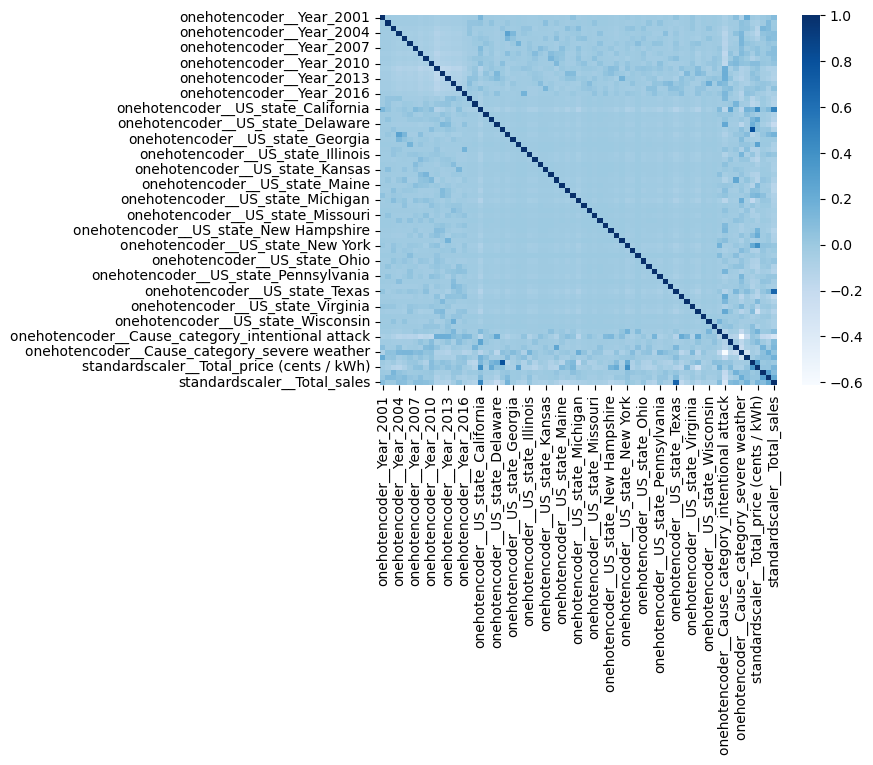

In [460]:
pre = pl.named_steps["columntransformer"]

X_transformed = pre.transform(X)

df_transformed = pd.DataFrame(
    X_transformed.toarray(),
    columns=pre.get_feature_names_out(),
    index=X.index,
)


sns.heatmap(df_transformed.corr(), cmap="Blues", fmt=".2f")

In [543]:
cleaned_df.dtypes

0
US_state                      object
Year                          object
Pc_realgsp_state ($)          object
Total_price (cents / kWh)    float64
Cause_category                object
Demand_loss_mw               float64
Customers_affected           float64
Total_sales                  float64
Outage_duration              float64
dtype: object

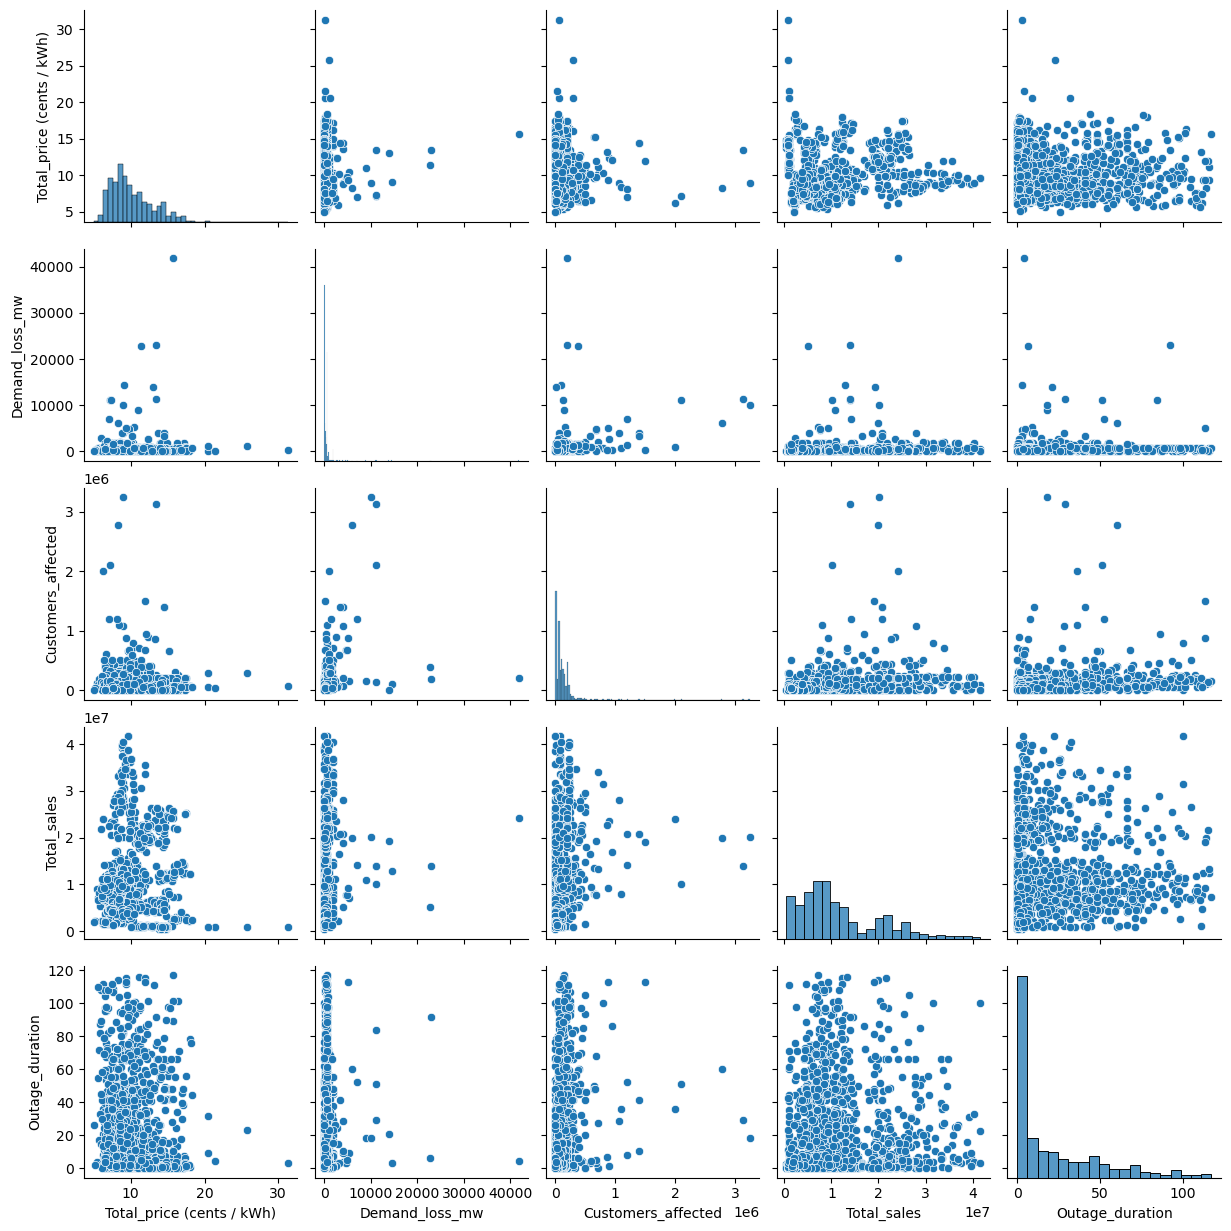

In [545]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(no_outliers.select_dtypes(exclude=["object"]))

In [467]:
pd.concat(
    [df_transformed, pd.DataFrame(y, columns=["Outage_duration"])], axis=1
).corr().iloc[:, -1]

onehotencoder__Year_2001                                      -0.023838
onehotencoder__Year_2002                                       0.029084
onehotencoder__Year_2003                                       0.061777
onehotencoder__Year_2004                                       0.066699
onehotencoder__Year_2005                                       0.087989
onehotencoder__Year_2006                                       0.026994
onehotencoder__Year_2007                                      -0.006907
onehotencoder__Year_2008                                       0.075679
onehotencoder__Year_2009                                       0.045249
onehotencoder__Year_2010                                       0.017049
onehotencoder__Year_2011                                      -0.063294
onehotencoder__Year_2012                                      -0.043864
onehotencoder__Year_2013                                      -0.068625
onehotencoder__Year_2014                                       0

## Step 7: Final Model

In [490]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [525]:
cleaned_df.shape

(1528, 9)

In [524]:
no_outliers.shape

(1384, 9)

In [523]:
# TODO
third_qrt = cleaned_df["Outage_duration"].quantile(0.75)
first_qrt = cleaned_df["Outage_duration"].quantile(0.25)
bound = 1.5 * (third_qrt - first_qrt)
no_outliers = cleaned_df[cleaned_df["Outage_duration"] <= third_qrt + bound]

# TODO
X = no_outliers[
    [
        "Year",
        "US_state",
        "Pc_realgsp_state ($)",
        "Total_price (cents / kWh)",
        "Cause_category",
        "Demand_loss_mw",
        "Customers_affected",
        "Total_sales",
    ]
]

y = no_outliers["Outage_duration"]

# final_df = cleaned_df.copy()

# final_df["price_income_ratio"] = (
#     final_df["Total_price (cents / kWh)"] / final_df["Pc_realgsp_state ($)"]
# )

# # final_df["Demand_loss_mw"] = np.log1p(final_df["Demand_loss_mw"])
# # final_df["Customers_affected"] = np.log1p(final_df["Customers_affected"])


# X = final_df[
#     [
#         "Pc_realgsp_state ($)",
#         "Total_price (cents / kWh)",
#         "Cause_category",
#         "Demand_loss_mw",
#         "Customers_affected",
#         "Total_sales",
#         # "price_income_ratio",
#     ]
# ]

# y = final_df["Outage_duration"]


# num_cols = [
#     "Pc_realgsp_state ($)",
#     "Total_price (cents / kWh)",
#     "Demand_loss_mw",
#     "Customers_affected",
#     "Total_sales",
#     # "price_income_ratio",
# ]

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    (StandardScaler(), num_cols),
)

pl = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=42),
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    "randomforestregressor__n_estimators": [100, 200, 300, 400, 500],
    "randomforestregressor__max_depth": [20, 25, 30],
    "randomforestregressor__min_samples_leaf": [1, 3, 5, 7, 9],
}

grid = GridSearchCV(
    pl,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)


mae, r2_score(y_test, pred)

/Users/wuyuming/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/wuyuming/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/wuyuming/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/wuyuming/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Use

(np.float64(13.863380178239636), 0.3777094749234021)

In [533]:
grid.best_params_

{'randomforestregressor__max_depth': 25,
 'randomforestregressor__min_samples_leaf': 3,
 'randomforestregressor__n_estimators': 400}

In [515]:
results = pd.DataFrame(grid.cv_results_)
results["mae"] = -results["mean_test_score"]

In [516]:
n_est_df = (
    results.groupby("param_randomforestregressor__n_estimators")["mae"]
    .mean()
    .reset_index()
)

fig1 = px.line(
    n_est_df,
    x="param_randomforestregressor__n_estimators",
    y="mae",
    markers=True,
    title="Effect of n_estimators on MAE",
)

fig1.show()

In [509]:
depth_df = (
    results.groupby("param_randomforestregressor__max_depth")["mae"]
    .mean()
    .reset_index()
)

fig2 = px.line(
    depth_df,
    x="param_randomforestregressor__max_depth",
    y="mae",
    markers=True,
    title="Effect of max_depth on MAE",
)

fig2.show()

In [510]:
leaf_df = (
    results.groupby("param_randomforestregressor__min_samples_leaf")["mae"]
    .mean()
    .reset_index()
)

fig3 = px.line(
    leaf_df,
    x="param_randomforestregressor__min_samples_leaf",
    y="mae",
    markers=True,
    title="Effect of min_samples_leaf on MAE",
)

fig3.show()

In [517]:
y_pred = best_model.predict(X_test)
plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
fig = px.scatter(
    plot_df,
    x="Actual",
    y="Predicted",
    title="Predicted vs Actual Outage Duration",
    labels={
        "Actual": "Actual Outage Duration",
        "Predicted": "Predicted Outage Duration",
    },
)

fig.show()

In [518]:
from sklearn.model_selection import cross_val_score

In [520]:
cross_val_score(best_model, X, y, cv=5, scoring="r2").mean()

np.float64(-0.5077119371980114)

In [50]:
# predicted vs actual outage duration after retransformation
y_pred = best_model.predict(X_test)

# Convert back to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

plot_df = pd.DataFrame(
    {"Actual": y_test_original, "Predicted": y_pred_original}
)

fig = px.scatter(
    plot_df,
    x="Actual",
    y="Predicted",
    title="Predicted vs Actual Outage Duration (Original Scale)",
    labels={
        "Actual": "Actual Outage Duration",
        "Predicted": "Predicted Outage Duration",
    },
)

fig.show()

In [51]:
final_df["Outage_duration"].mean()

NameError: name 'final_df' is not defined

## Step 8: Fairness Analysis

In [799]:
# TODO